# PHASE TWO PROJECT

##  A DATA-DRIVEN LOOK AT MOVIE PROFITS

![Aviation accidents trend and factors](Images/OIP.jpg)

For this project I will be using data set obtained in the **'data_set.ipynb'** notebook and stored in the **movies.csv** in the Data folder.

This data was obtained by joining cleaning and formarting data from the **im.db** file and **bom.movie_gross.csv** file

## OBJECTIVES

I will use the data to:
- Analyze movie profitability trends by examining the relationship between features like runtime, rating, genre, and revenue
- Identify key factors that contribute to a movies commercial success
- Explore temporal trends in movie performance
- Develop a prediction model on total gross in diffrent genres

In [102]:
#Importing laibraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [103]:
#Loading data from movie.csv
df = pd.read_csv('DATA/movies.csv')
df.head()

,movie,year,genres,runtime_minutes,averagerating,numvotes,studio,domestic_gross,foreign_gross
0,Wazir,2016,"['Action', 'Crime', 'Drama']",103.0,7.1,15378,Relbig.,1100000.0,0.0
1,On the Road,2012,"['Adventure', 'Drama', 'Romance']",124.0,6.1,37886,IFC,744000.0,8000000.0
2,The Secret Life of Walter Mitty,2013,"['Adventure', 'Comedy', 'Drama']",114.0,7.3,275300,Fox,58200000.0,129900000.0
3,A Walk Among the Tombstones,2014,"['Action', 'Crime', 'Drama']",114.0,6.5,105116,Uni.,26300000.0,26900000.0
4,Jurassic World,2015,"['Action', 'Adventure', 'Sci-Fi']",124.0,7.0,539338,Uni.,652300000.0,1019.4


In [104]:
#1st I need to create a new column called profits which is a 
#total-sumation(foreign + domestic gross) of both domestic and foreign gross revenue generated by every movie

df['total_gross'] = df['domestic_gross'] +df['foreign_gross']
df.head()

,movie,year,genres,runtime_minutes,averagerating,numvotes,studio,domestic_gross,foreign_gross,total_gross
0,Wazir,2016,"['Action', 'Crime', 'Drama']",103.0,7.1,15378,Relbig.,1100000.0,0.0,1100000.0
1,On the Road,2012,"['Adventure', 'Drama', 'Romance']",124.0,6.1,37886,IFC,744000.0,8000000.0,8744000.0
2,The Secret Life of Walter Mitty,2013,"['Adventure', 'Comedy', 'Drama']",114.0,7.3,275300,Fox,58200000.0,129900000.0,188100000.0
3,A Walk Among the Tombstones,2014,"['Action', 'Crime', 'Drama']",114.0,6.5,105116,Uni.,26300000.0,26900000.0,53200000.0
4,Jurassic World,2015,"['Action', 'Adventure', 'Sci-Fi']",124.0,7.0,539338,Uni.,652300000.0,1019.4,652301019.4


## Objective 1: Analyze movie profitability trends by examining the relationship between features like runtime, rating, genre, and revenue

### Total gross distribution

This will show us how the total gross generated accross the data set is distributed

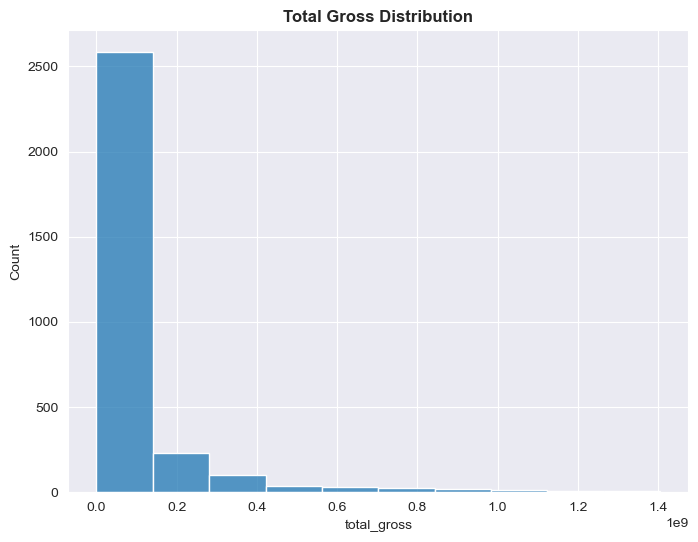

In [107]:
plt.figure(figsize = (8, 6))

sns.histplot(data = df, x = 'total_gross', bins = 10)
plt.title('Total Gross Distribution', weight = 'bold')
sns.set_style('darkgrid')
plt.show()

### 1. Runtime vs total_gross

Here we will look at how runtime affects the total gross a movie makes

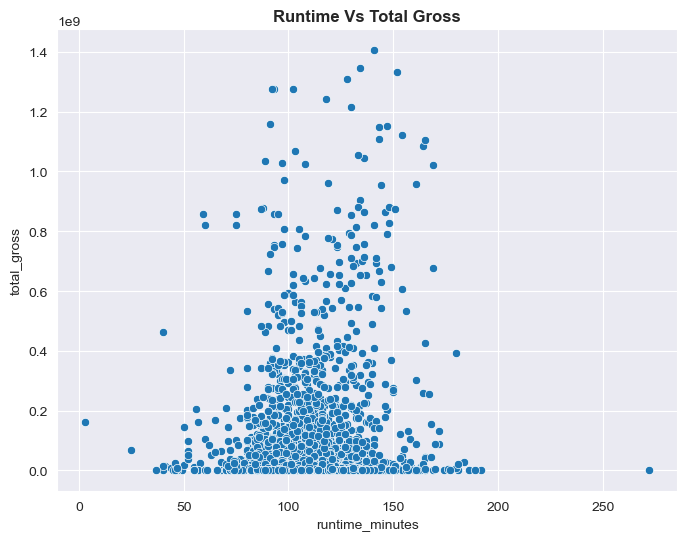

In [110]:
#create a figure to plot our scatter plot
plt.figure(figsize = (8, 6))

#PLot runtime vs total gross
sns.scatterplot(data = df, x = df['runtime_minutes'], y = df['total_gross'])
plt.title('Runtime Vs Total Gross', weight = 'bold')
sns.set_style('darkgrid')
plt.show()

### 2. Average Rating vs. Total Gross

Now lets look at how ratings impact total gross

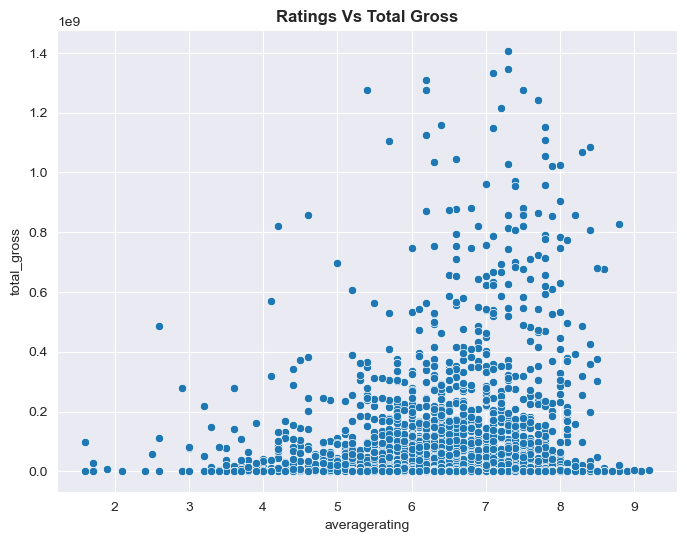

In [113]:
#Create a figure for our plot
plt.figure(figsize = (8, 6))

#plot ratings vs total gross
sns.scatterplot(data = df, x = df['averagerating'], y = df['total_gross'])
plt.title('Ratings Vs Total Gross', weight = 'bold')
sns.set_style('darkgrid')
plt.show()

### 3. Number of Votes vs. Total Gross

These will show us how popularity impacts movie sales

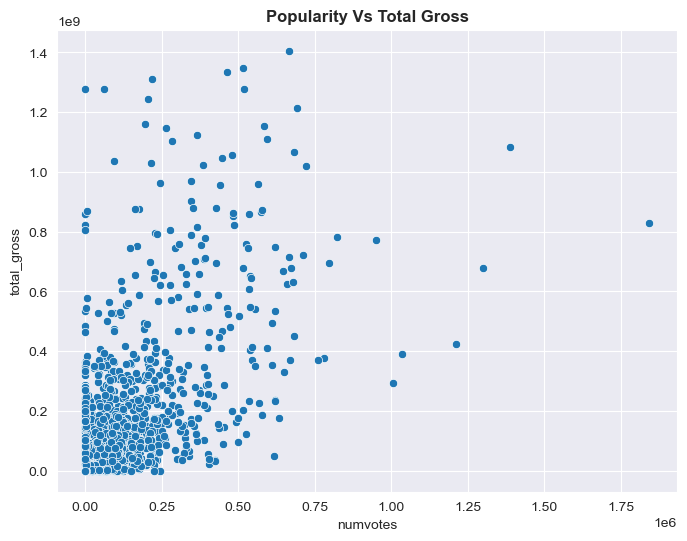

In [116]:
plt.figure(figsize = (8, 6))

sns.scatterplot(data = df, x = df['numvotes'], y = df['total_gross'])
plt.title('Popularity Vs Total Gross', weight = 'bold')
sns.set_style('darkgrid')
plt.show()

### 4. Correlation of ratings, popularity and runtime to gross total

This will help us identify whch features have strong and negative correlation to the gross total

In [119]:
df[['runtime_minutes', 'numvotes', 'averagerating', 'total_gross']].corr()

,runtime_minutes,numvotes,averagerating,total_gross
runtime_minutes,1.000000,0.260339,0.145239,0.151571
numvotes,0.260339,1.000000,0.283495,0.656075
averagerating,0.145239,0.283495,1.000000,0.121542
total_gross,0.151571,0.656075,0.121542,1.000000


**From the above we can see that popularity('numvotes') has the highest positive correlation meaning the popularity boosts revenue generated**

## Objective 2: Identify key factors that contribute to a movies commercial success

This part we will look more closely at the genres

The questions we are going to answer are:
- Which genres are most profitable
- Do highly rated genres earn more
- Are popular genres also the most profitable

But scince our genre column contains a list of all the diffrent genres a single movie belongs to, we need to use **.explode()** to split every genre into a row on its own then **group by** genre for analysis

### 1. Expanding the genre column using explode() function

In [152]:
#Exploding the genre column
df['genres'] = df['genres'].str.strip("[]'\" ")
df = df.assign(genres=df['genres'].str.split(',')).explode('genres')
df.head(10)

,movie,year,genres,runtime_minutes,averagerating,numvotes,studio,domestic_gross,foreign_gross,total_gross
0,Wazir,2016,Action,103.0,7.1,15378,Relbig.,1100000.0,0.0,1100000.0
0,Wazir,2016,Crime,103.0,7.1,15378,Relbig.,1100000.0,0.0,1100000.0
0,Wazir,2016,Drama,103.0,7.1,15378,Relbig.,1100000.0,0.0,1100000.0
1,On the Road,2012,Adventure,124.0,6.1,37886,IFC,744000.0,8000000.0,8744000.0
1,On the Road,2012,Drama,124.0,6.1,37886,IFC,744000.0,8000000.0,8744000.0
1,On the Road,2012,Romance,124.0,6.1,37886,IFC,744000.0,8000000.0,8744000.0
2,The Secret Life of Walter Mitty,2013,Adventure,114.0,7.3,275300,Fox,58200000.0,129900000.0,188100000.0
2,The Secret Life of Walter Mitty,2013,Comedy,114.0,7.3,275300,Fox,58200000.0,129900000.0,188100000.0
2,The Secret Life of Walter Mitty,2013,Drama,114.0,7.3,275300,Fox,58200000.0,129900000.0,188100000.0
3,A Walk Among the Tombstones,2014,Action,114.0,6.5,105116,Uni.,26300000.0,26900000.0,53200000.0


### 2. Group by Genre then summarize the total gross by genre

Now we summarize profitability and popularity per genre

In [158]:
#Grouping by genres and summarizing by profitability and popularity
df_summary = df.groupby('genres').agg(
    avg_total_gross=('total_gross', 'mean'),
    median_total_gross=('total_gross', 'median'),
    avg_rating=('averagerating', 'mean'),
    avg_votes=('numvotes', 'mean'),
    count=('genres', 'count')
).sort_values(by='avg_total_gross', ascending=False)

df_summary

,avg_total_gross,median_total_gross,avg_rating,avg_votes,count
genres,,,,,
Sci-Fi,2.842401e+08,132450000.0,6.455147,245906.779412,136
Adventure,2.732155e+08,150050000.0,6.491964,158102.066964,448
Animation,2.525529e+08,119400000.0,6.721519,87334.360759,158
Fantasy,1.696389e+08,52300000.0,6.258857,110138.342857,175
Action,1.653266e+08,54400000.0,6.293435,123295.346565,655
Family,1.297424e+08,47100000.0,6.220168,54729.033613,119
Comedy,8.274729e+07,13100000.0,6.256092,59249.539916,952
Sport,7.978087e+07,12100000.0,6.915094,52877.226415,53
Thriller,7.781469e+07,14100000.0,6.177232,79502.198661,448


### 3. Visualizing Factors/Insights 

After our data is summarized we can now visualize it to get a visual representation of the key factors that contribute to a movies commercial success 

### Top 10 genres by average total gross

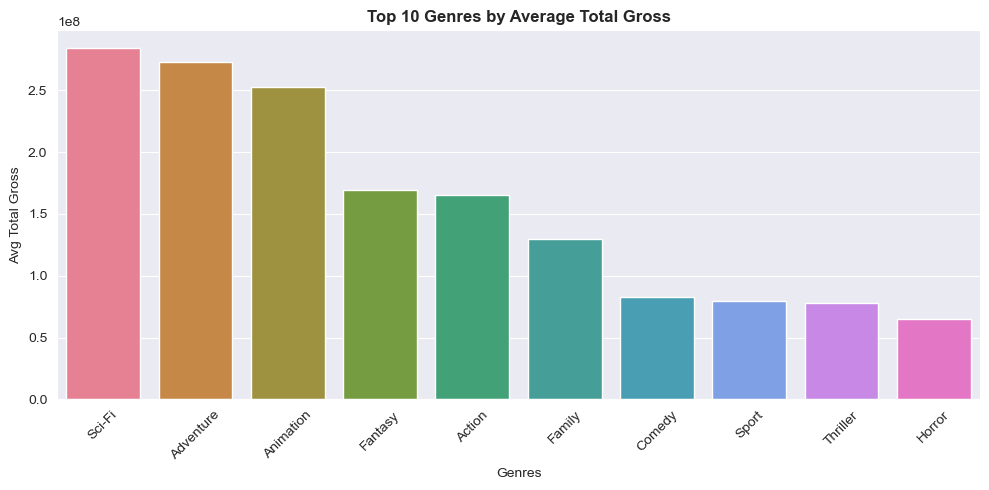

In [185]:
#Get the most profitable genres
top_genres = df_summary.head(10)
top_genres = top_genres.reset_index()

#Plot a bar graph to represent them
plt.figure(figsize = (10, 5))

#making each bar have a ditinct color
palette = sns.color_palette("husl", len(top_genres))

sns.barplot(data  = top_genres, x = 'genres', y = 'avg_total_gross', hue='genres', palette = palette)
plt.title('Top 10 Genres by Average Total Gross', weight = 'bold')
plt.xlabel('Genres')
plt.ylabel('Avg Total Gross')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Ratings and popularity vs Gross per Genre

Now we take a look at how ratings against gross per genre

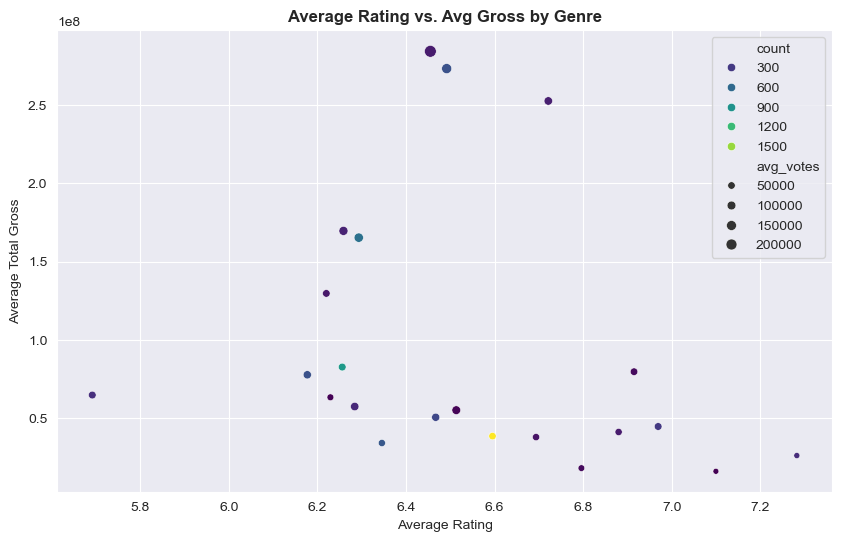

In [328]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_summary, x='avg_rating', y='avg_total_gross', size='avg_votes', hue='count', palette='viridis', legend=True)
plt.title('Average Rating vs. Avg Gross by Genre', weight = 'bold')
plt.xlabel('Average Rating')
plt.ylabel('Average Total Gross')
plt.grid(True)
plt.show()

So from the above scatter plot we can clearly answer the questions for this obectives
- The bar plot shows the most profitble 10 genres
- As for highly rated genres making more gross revenue the answer is yes and no as seen on the scatter plot
- As popularity being a factor to making money then yes because the most popular genre is the most profitable

## Objective 3: Trends in Movie performance

Here we are going to take a look on how movies generes years and popularity eveolved over the years


In [209]:
#Ensure the year column is the right data type
df['year'].dtype

dtype('int64')

Since the data type is correct we can start looking at the trends

### Trend of movies released per year

This will informorm us if the number of movies are increasing as time goes by or decreasing


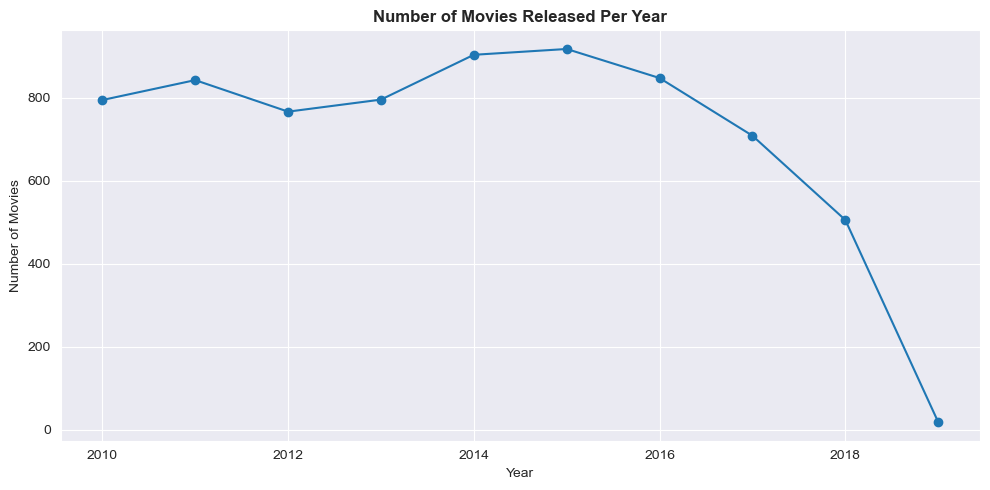

In [216]:
#group the data by year 1st
movies_per_year = df.groupby('year').size()

#plot a line grapgh to show the trend
movies_per_year.plot(kind='line', figsize=(10, 5), marker='o')
plt.title('Number of Movies Released Per Year', weight = 'bold')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.grid(True)
plt.tight_layout()
plt.show()

### Average Gross Over Time

THis will help how show how the market trend in terms of revenue generated by movies has changed over the years

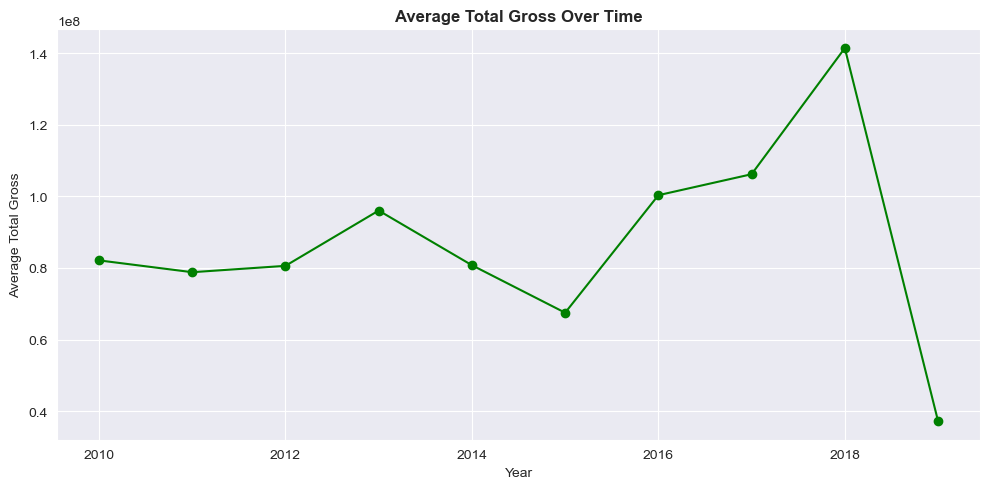

In [229]:
# Group by total gross and year then find the average gross in every year
avg_gross_by_year = df.groupby('year')['total_gross'].mean()

#plot the graph
avg_gross_by_year.plot(kind='line', figsize=(10, 5), color='green', marker='o')
plt.title('Average Total Gross Over Time', weight = 'bold')
plt.xlabel('Year')
plt.ylabel('Average Total Gross')
plt.grid(True)
plt.tight_layout()
plt.show()

This show that the general trejetory in revenue generated ofver the years is going up indicating that this might be good invetment 

### Average Rating Over Time

This will help tell us whether the quality of movies have declined or improved over time


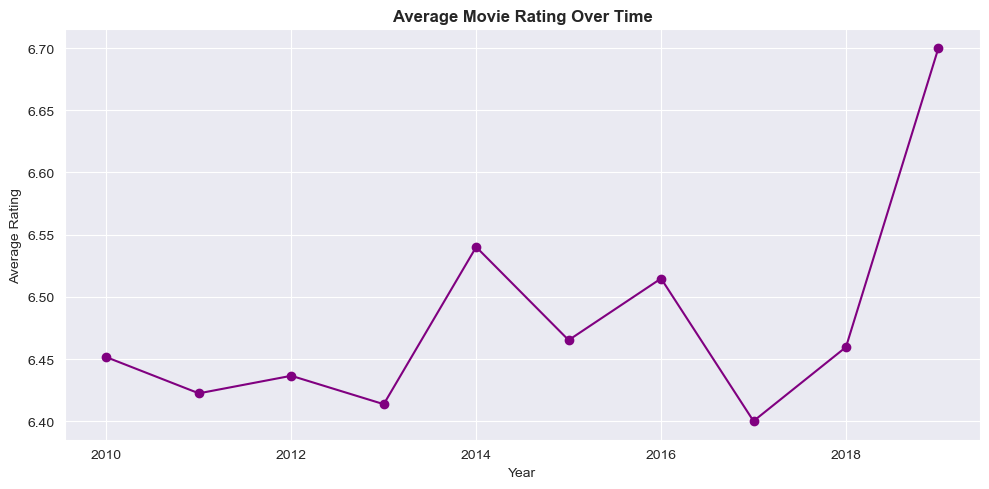

In [234]:
#group by year and ratings an find the avarage rating in each year
avg_rating_by_year = df.groupby('year')['averagerating'].mean()

#plot the graph
avg_rating_by_year.plot(kind='line', figsize=(10, 5), color='purple', marker='o')
plt.title('Average Movie Rating Over Time', weight = 'bold')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.grid(True)
plt.tight_layout()
plt.show()

### Movie popularity over Time

This will show how movies popularity are affected by time

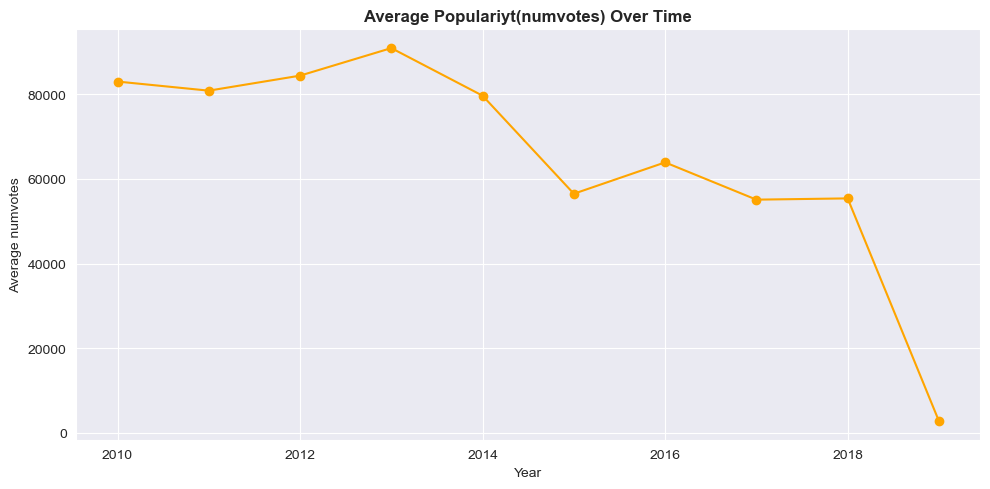

In [238]:
#group by year and find the avarage number of votesin each year
avg_pop_by_yr = df.groupby('year')['numvotes'].mean()

#plot the popularity graph
avg_pop_by_yr.plot(kind='line', figsize=(10, 5), color='orange', marker='o')
plt.title('Average Populariyt(numvotes) Over Time', weight = 'bold')
plt.xlabel('Year')
plt.ylabel('Average numvotes')
plt.grid(True)
plt.tight_layout()
plt.show()

This indicates that the popularity of ovies has gone down over time

### Genre trends over Time

Here we will be looking at how trends in genre has evolved over time

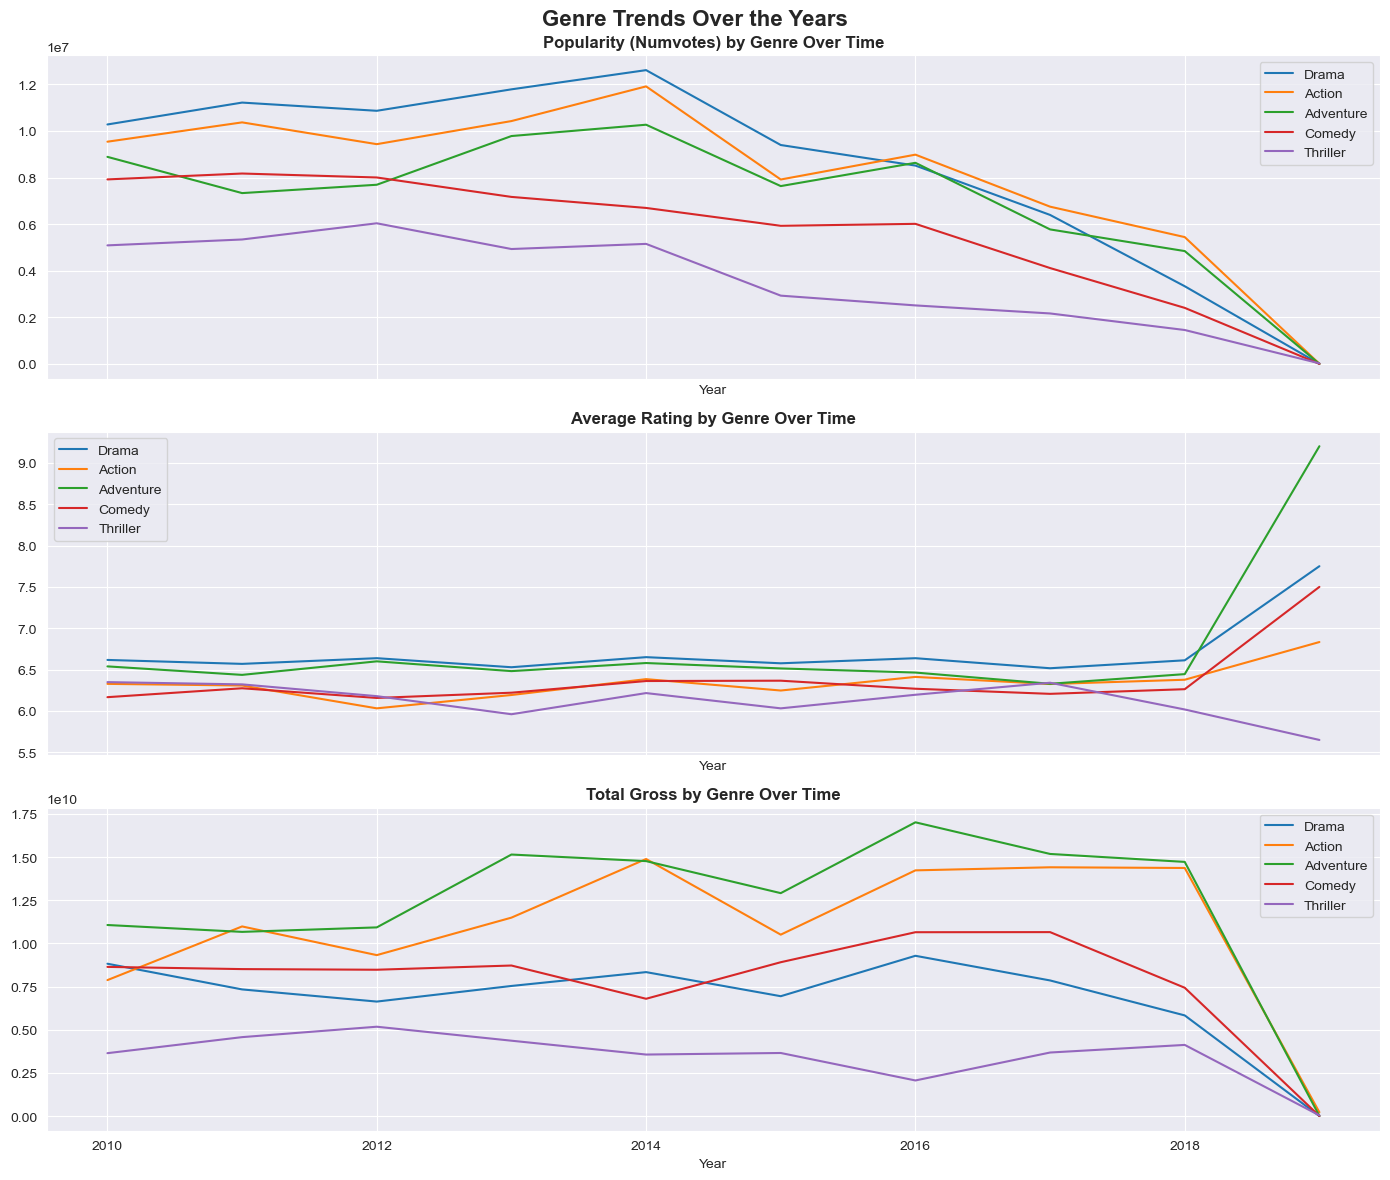

In [269]:
# Group by year and genre
grouped = df.groupby(['year', 'genres'])

# Sum of numvotes (popularity) instead of count of movies
popularity_by_genre = grouped['numvotes'].sum().unstack(fill_value=0)
avg_rating_by_genre = grouped['averagerating'].mean().unstack(fill_value=0)
total_gross_by_genre = grouped['total_gross'].sum().unstack(fill_value=0)

# Top 5 genres by popularity
top_genres = popularity_by_genre.sum().sort_values(ascending=False).head().index

# Create a figure for our subplots
fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Popularity (numvotes) by genre
for genre in top_genres:
    axs[0].plot(popularity_by_genre.index, popularity_by_genre[genre], label=genre)
axs[0].set_title("Popularity (Numvotes) by Genre Over Time", weight='bold')
axs[0].set_xlabel("Year")
axs[0].legend()
axs[0].grid(True)

# Average rating by genre
for genre in top_genres:
    axs[1].plot(avg_rating_by_genre.index, avg_rating_by_genre[genre], label=genre)
axs[1].set_title("Average Rating by Genre Over Time", weight='bold')
axs[1].set_xlabel("Year")
axs[1].legend()
axs[1].grid(True)

# Total gross by genre
for genre in top_genres:
    axs[2].plot(total_gross_by_genre.index, total_gross_by_genre[genre], label=genre)
axs[2].set_title("Total Gross by Genre Over Time", weight='bold')
axs[2].set_xlabel("Year")
axs[2].legend()
axs[2].grid(True)

plt.suptitle('Genre Trends Over the Years', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Objective 4: Develop linear regression model to predict total_gross based on popularity, genre

So far our work has been to explore our data for insights and we have gained multiple insights for profits and trends.

Now if we want to start and establish our own studio we need to make projections on revenue generated so as to have an esstimate of the buget needed to meet the profit mergin

For this I will need to import the sklearn library for my model

In [262]:
#Importing Librries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import mean_squared_error, r2_score

In [273]:
#One-hot encode the single-genre-per-row(This will generate a df where the diferent genres are represneted by 1s and 0s)
genre_dummies = pd.get_dummies(df['genres'])

# Combine with original
df_encoded = pd.concat([df[['movie', 'numvotes', 'total_gross']], genre_dummies], axis=1)

# Group by movie to aggregate genre dummies (sum will work since each is 0/1)
df_grouped = df_encoded.groupby('movie').agg({
    'numvotes': 'first',
    'total_gross': 'first',
    **{genre: 'max' for genre in genre_dummies.columns}  # Use 'max' because a genre is either present (1) or not (0)
}).reset_index()

# Features and target
X = df_grouped.drop(columns=['movie', 'total_gross'])
y = df_grouped['total_gross']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.2f}')
print(f'R-squared: {r2:.2f}')

RMSE: 93809014.83
R-squared: 0.67


In [275]:
#Create a DataFrame with predictions and movie names
y_pred = model.predict(X_test)

results = X_test.copy()
results['actual_total_gross'] = y_test
results['predicted_total_gross'] = y_pred

#Bring back the movie names
results = results.merge(df_grouped[['movie']], left_index=True, right_index=True, how='left')

#Merge with exploded genres so each row = one genre per movie
genre_results = results.merge(df[['movie', 'genres']], on='movie', how='left')

#Group by genre and compute mean
genre_summary = genre_results.groupby('genres').agg({
    'actual_total_gross': 'mean',  # or 'sum' depending on your goal
    'predicted_total_gross': 'mean'
}).reset_index()

#Optional - calculate error or difference
genre_summary['abs_error'] = abs(genre_summary['actual_total_gross'] - genre_summary['predicted_total_gross'])


genre_summary.sort_values('abs_error')

,genres,actual_total_gross,predicted_total_gross,abs_error
5,Crime,4.655300e+07,4.827881e+07,1.725809e+06
2,Animation,2.716039e+08,2.743066e+08,2.702618e+06
14,Mystery,3.751651e+07,4.184209e+07,4.325582e+06
8,Family,1.274024e+08,1.320102e+08,4.607849e+06
10,History,6.502323e+07,7.020968e+07,5.186453e+06
16,Romance,3.319556e+07,2.775796e+07,5.437600e+06
4,Comedy,8.337676e+07,8.900668e+07,5.629922e+06
18,Sport,1.074201e+08,1.010393e+08,6.380777e+06
9,Fantasy,1.713131e+08,1.777635e+08,6.450436e+06
7,Drama,3.699211e+07,4.349329e+07,6.501182e+06


### PLot a prediction graph

#### Scatterlot of Actual Vs Predicted Gross

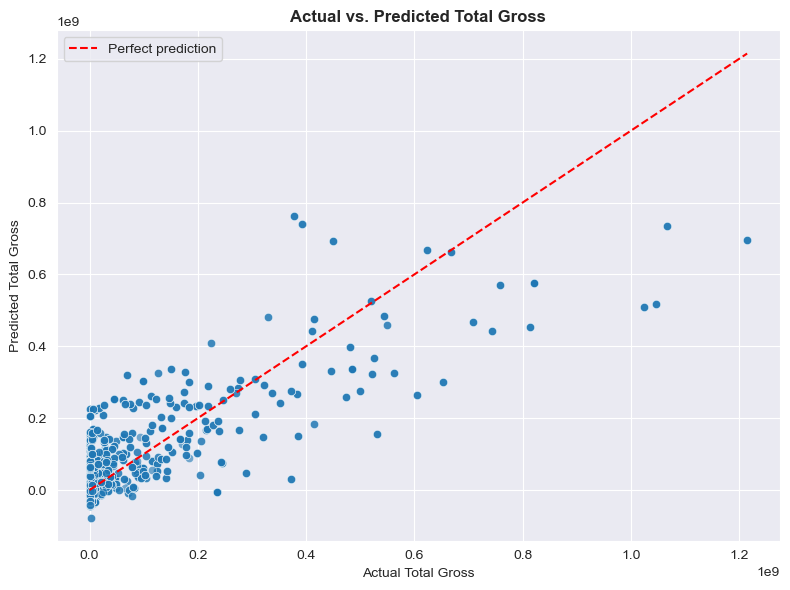

In [280]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=genre_results['actual_total_gross'], y=genre_results['predicted_total_gross'], alpha=0.6)

# Plot ideal line
max_val = max(genre_results['actual_total_gross'].max(), genre_results['predicted_total_gross'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Perfect prediction')

plt.xlabel('Actual Total Gross')
plt.ylabel('Predicted Total Gross')
plt.title('Actual vs. Predicted Total Gross', weight = 'bold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Bargraph of Mean Actual vs predicted Gross

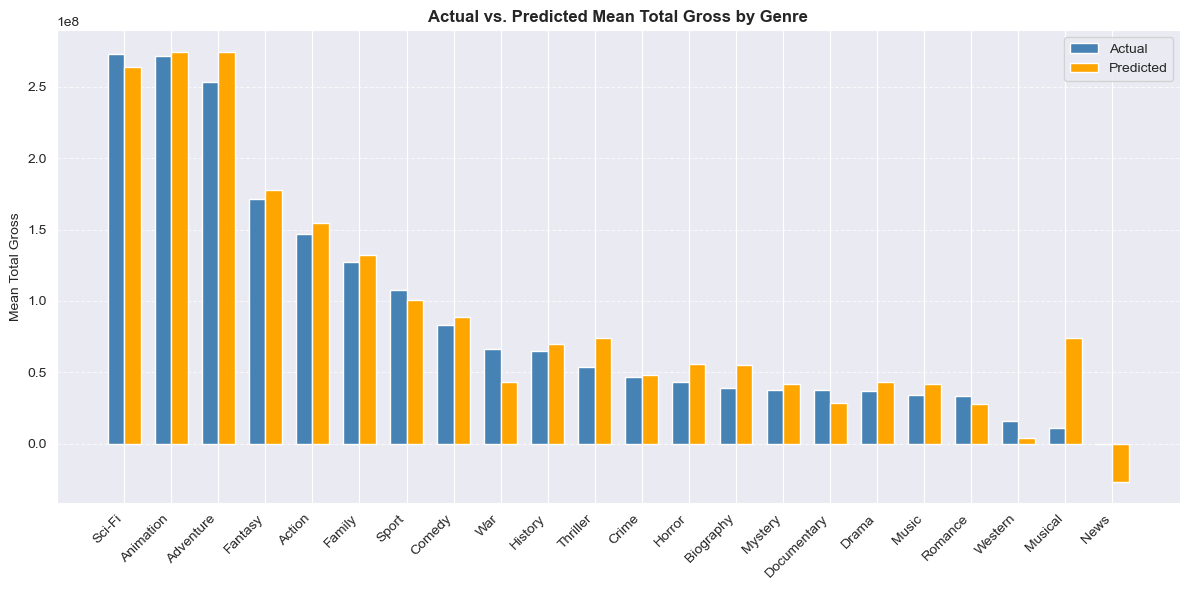

In [294]:
# Sort genres by actual gross for clarity
genre_summary_sorted = genre_summary.sort_values('actual_total_gross', ascending=False)

# Bar positions
x = np.arange(len(genre_summary_sorted))  # Numeric x positions
width = 0.35  # Width of each bar

# Actual and predicted values
actual = genre_summary_sorted['actual_total_gross']
predicted = genre_summary_sorted['predicted_total_gross']

# Plot bars side by side
plt.figure(figsize=(12, 6))
plt.bar(x - width/2, actual, width, label='Actual', color='steelblue')
plt.bar(x + width/2, predicted, width, label='Predicted', color='orange')

# X-axis labels and formatting
plt.xticks(x, genre_summary_sorted['genres'], rotation=45, ha='right')
plt.ylabel('Mean Total Gross')
plt.title('Actual vs. Predicted Mean Total Gross by Genre', weight = 'bold')
plt.legend()
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

### Conclusions

- popularity('numvotes') has the highest positive correlation meaning the popularity boosts revenue generated
- The bar plot shows the most profitble 10 genres
- As for highly rated genres making more gross revenue the answer is yes and no as seen on the scatter plot
- As popularity being a factor to making money then yes because the most popular genre is the most profitable